# Env

In [20]:
# 魔法指令：只要您在 vim 修改了 .py 檔，這裡會自動重新載入，不用重啟 Kernel！
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
from dataset import get_mnist_dataloaders
from models import CNN_Net, Perceptron
from engine import train_model, evaluate_model
from utils import get_device, plot_loss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hyper param and Data

In [17]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 5
MODEL_TYPE = 'CNN' # 可以隨時改成 'MLP' 來測試不同的架構

# 取得硬體與資料
device = get_device()
print(f"目前使用的運算設備: {device}")
train_loader, test_loader = get_mnist_dataloaders(batch_size=BATCH_SIZE)

目前使用的運算設備: cuda


# Model and Train Param

In [18]:
if MODEL_TYPE == 'CNN':
    model = CNN_Net().to(device)
    torch.backends.cudnn.benchmark = True # CNN 專屬加速
else:
    model = Perceptron().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 印出參數總數量
params = sum(p.numel() for p in model.parameters())
print(f"模型總參數數量: {params:,}")

模型總參數數量: 108,618


# Train and Evaluate

In [22]:
loss_history = train_model(model, train_loader, criterion, optimizer, device, epochs=EPOCHS)# 繪製訓練曲線

開始訓練，總共 5 Epochs...


Epoch 5 	Training Loss: 0.0048: 100%|█████████████████████████████████████| 5/5 [00:22<00:00,  4.56s/it]


訓練總耗時: 0:00:23


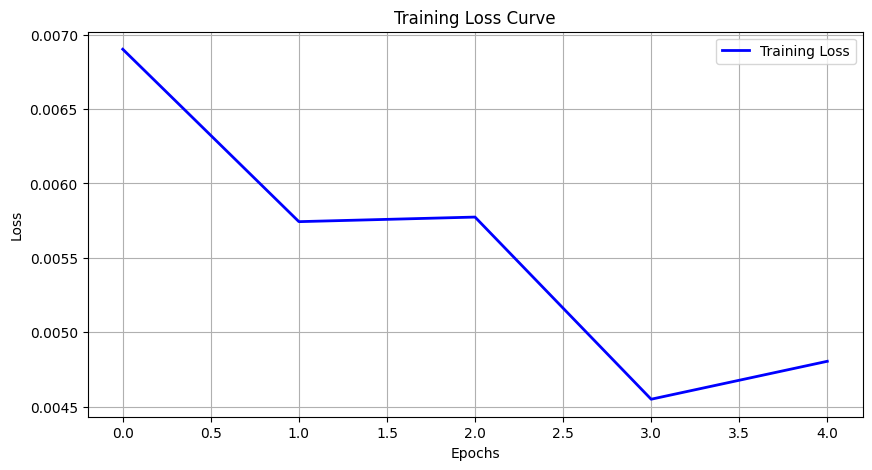

Test Accuracy: 99.05%


In [23]:
plot_loss(loss_history)
accuracy = evaluate_model(model, test_loader, device)
torch.save(model.state_dict(), 'mnist_20260331.pth')

# 載入模型並匯出為 ONNX

In [27]:
import torch
from models import CNN_Net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_Net().to(device)
model.load_state_dict(torch.load('mnist_20260331.pth'))
model.eval()

dummy_input = torch.randn(1, 1, 28, 28).to(device)
onnx_file_path = "mnist_cnn.onnx"

# 使用順應 PyTorch 最新 Dynamo 引擎的寫法
torch.onnx.export(
  model, 
  dummy_input, 
  onnx_file_path,
  export_params=True,
  opset_version=18,  # 🆙 更新到較新的 Opset 18
  do_constant_folding=True,
  input_names=['input'],
  output_names=['output'],
  # 如果只是單純參加 Kaggle，測試集數量固定，其實可以先移除動態 Batch Size 的設定，保持最簡潔
)
print(f"ONNX 模型已成功匯出至: {onnx_file_path}")

[torch.onnx] Obtain model graph for `CNN_Net([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN_Net([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX 模型已成功匯出至: mnist_cnn.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


# 在 Python 中使用 ONNX Runtime 進行推論

In [30]:
import onnxruntime as ort
import numpy as np

# 1. 啟動 ONNX 推論會話 (Inference Session)
# 在實際專案中，這裡可以指定使用 GPU 加速 (providers=['CUDAExecutionProvider'])
ort_session = ort.InferenceSession("mnist_cnn.onnx")

# 2. 準備一張 NumPy 格式的測試圖片 (模擬真實輸入)
x_numpy = np.random.randn(1, 1, 28, 28).astype(np.float32)

# 3. 執行推論 (不依賴 PyTorch)
# 注意這裡的 'input' 必須與匯出時指定的 input_names 一致
ort_inputs = {'input': x_numpy}
ort_outputs = ort_session.run(None, ort_inputs)

# 取得預測結果
predicted_logits = ort_outputs[0]
predicted_class = np.argmax(predicted_logits, axis=1)
print(f"ONNX 模型預測的類別為: {predicted_class[0]}")

ONNX 模型預測的類別為: 2


# 讀取 Kaggle 試題，生成 Submission 檔案

In [38]:
import pandas as pd
from dataset import get_kaggle_test_loader

# 載入 Kaggle 測試集資料管線 (請確保路徑正確)
kaggle_test_loader = get_kaggle_test_loader(csv_path='test.csv')

predictions = []

# 使用原本的 PyTorch model 進行大規模預測 (因為您還在訓練階段的 Notebook 裡)
model.eval()
with torch.no_grad():
    for images in kaggle_test_loader:
        images = images.to(device)
        outputs = model(images)
        # 找出機率最高的那一個類別
        _, preds = torch.max(outputs, 1)
        
        # 將 GPU 上的張量搬回 CPU，並轉成 Python 的 list
        predictions.extend(preds.cpu().numpy().tolist())

print(f"成功預測 {len(predictions)} 筆資料！")

# 依照 Kaggle 規定的格式：ImageId (從 1 開始) 與 Label
submission_df = pd.DataFrame({
    'ImageId': range(1, len(predictions) + 1),
    'Label': predictions
})

# 存檔，不包含 index 欄位
submission_df.to_csv('submission.csv', index=False)
print("submission.csv 已生成！您可以從 Kaggle 側邊欄下載，或直接提交比賽。")

成功預測 28000 筆資料！
submission.csv 已生成！您可以從 Kaggle 側邊欄下載，或直接提交比賽。
